Sales Data Analysis
Analysis of sales dataset using Python (Pandas)

OBJECTIVE
The goal of this analysis is to identify sales trends, top-performing categories and key grographic insights.

DATASET DESCRIPTION
The dataset contains info about orders, including city, category, sub-category, sales and others.

In [4]:
import pandas as pd
train = pd.read_csv('/Users/francescalovecchio/Downloads/train.csv')

In [5]:
train.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [6]:
train.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [7]:
train.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object

In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [9]:
train['Sales'].sum()

np.float64(2261536.7827)

In [10]:
#Which categories sell the most?
train.groupby('Category')['Sales'].sum()

Category
Furniture          728658.5757
Office Supplies    705422.3340
Technology         827455.8730
Name: Sales, dtype: float64

In [11]:
#sales by country
train.groupby('Country')['Sales'].sum().sort_values(ascending=False)

Country
United States    2.261537e+06
Name: Sales, dtype: float64

In [12]:
#Which city sell the most?
train.groupby('City')['Sales'].sum().sort_values(ascending =False).head()

City
New York City    252462.547
Los Angeles      173420.181
Seattle          116106.322
San Francisco    109041.120
Philadelphia     108841.749
Name: Sales, dtype: float64

In [16]:
#cosa si vende di più a new york?
train[train['City'] == 'New York City'].groupby('Category')['Sales'].sum()

Category
Furniture           74822.885
Office Supplies     68659.526
Technology         108980.136
Name: Sales, dtype: float64

In [23]:
#find sub-category
train[train['City'] == 'New York City'].groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)

Sub-Category
Chairs         39576.519
Phones         37623.160
Machines       37531.210
Binders        23324.536
Storage        20060.080
Accessories    17105.910
Bookcases      17019.032
Copiers        16719.856
Appliances     12281.430
Tables         10964.094
Furnishings     7263.240
Paper           6847.240
Art             2128.080
Supplies        1562.210
Envelopes       1199.570
Labels          1042.720
Fasteners        213.660
Name: Sales, dtype: float64

Sales are concentrated primarily in the technology category.
The city with the highest sales volume is New York.
Within these categories, the best-selling products are chairs, phones, and cars.
This suggests strong demand for both "pure" technology products (phones)
and "converted" technology products (chairs, cars).

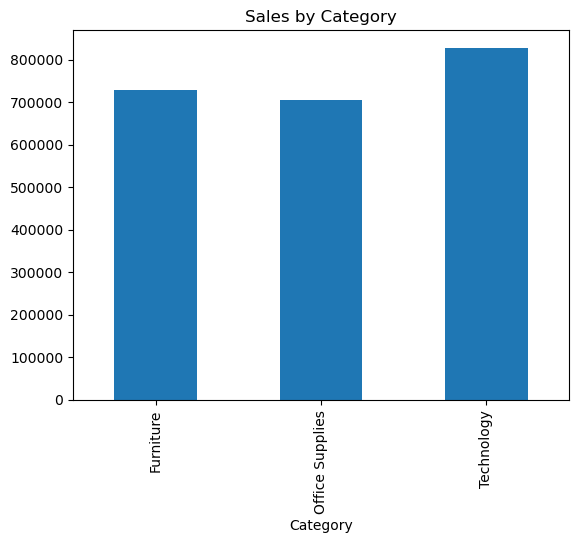

In [34]:
import matplotlib.pyplot as plt

train.groupby('Category')['Sales'].sum().plot(kind='bar')
plt.title('Sales by Category')
plt.show()

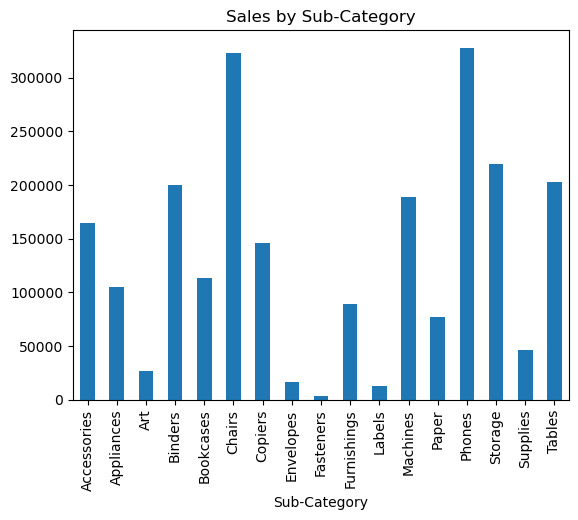

In [35]:
train.groupby('Sub-Category')['Sales'].sum().plot(kind='bar')
plt.title('Sales by Sub-Category')
plt.show()

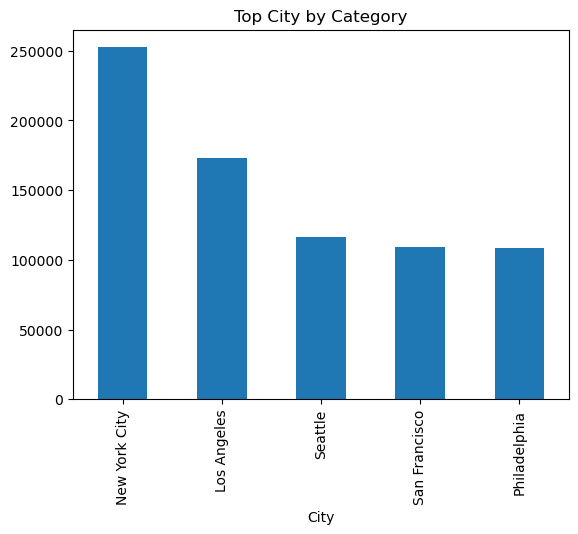

In [37]:
train.groupby('City')['Sales'].sum().sort_values(ascending=False).head().plot(kind='bar')
plt.title('Top City by Category')
plt.show()

## Key Insights

- Technology is the top-performing category
- New York City generates the highest sales
- Top-selling products include phones, chairs, and machines

## Business Recommendations

- Focus marketing efforts on top-performing categories
- Strengthen presence in high-performing cities like New York
- Optimize inventory for best-selling products

In [38]:
train['Sales'].describe()

count     9800.000000
mean       230.769059
std        626.651875
min          0.444000
25%         17.248000
50%         54.490000
75%        210.605000
max      22638.480000
Name: Sales, dtype: float64